The notebook is used for testing saving and loading model capability

In [ ]:
import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

import equinox as eqx

import optax

from DiffFlowTransport.transport import SASTransport
from DiffFlowTransport.flow import LSTM
# from DiffFlowTransport.sas import SAS_Gamma, SAS_Uniform, SAS_Gamma_VaryingScale
# from DiffFlowTransport.sas import SAS_NormalMDN, SAS_GammaMDN
from DiffFlowTransport.sas import initialize_sas_model
from DiffFlowTransport.utils import load_transport_model, save_transport_model
from DiffFlowTransport.utils import load_flow_model, save_flow_model
from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_ST, plot_PQET_quantile

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


In [ ]:
import numpy as np
np.random.random(4,5)

# Read the data

In [3]:
df = pd.read_csv('./data.csv', index_col=1)
df.index = pd.to_datetime(df.index, format='%m/%d/%y')
df.head()

,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


In [15]:
J = jnp.array(df['J'].values)
Q = jnp.array(df['Q'].values)
ET = jnp.array(df['ET'].values)
C_J = jnp.array(df['Cl mg/l'].values)
C_Q_J = jnp.array(df['Q Cl mg/l'].values)


# Transport model

## Parameters

In [19]:
# Parameters
params = {
    "dt": 1.,
    "α_Q": 1.,
    "α_ET": 0.,
    "k1": [0.],
    "C_eq": [0.],
    # "C_Q_old": [0.],
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() / (1-0.26)]
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() * (1-0.26)]
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean()]
    "C_Q_old": [6.]
}

# # Other arguments for running the model

# SAS parameters
sas_params = {
    "Q SAS fun": {
        "func": "NormalMDN",
        "args": {
            "scale": 8215.0,
            "n_input": 1,
            "n_hidden": 10,
            "n_mixture": 5,
            "key": 42,
            "width_size": 10,
            "depth": 2
        }
    },
    "ET SAS fun": {
        "func": "Uniform",
        "args": {
            "scale": 737.0
        }
    }
}

transport_params = {
    "transport_specs": params,
    "sas_specs": sas_params
}


## Initialize the model

In [8]:
# Initialize the model
sas_Q = initialize_sas_model(sas_params['Q SAS fun'])
sas_ET = initialize_sas_model(sas_params['ET SAS fun'])

# Initialize the SAS transport model
model_mdn = SASTransport(sas_Q, sas_ET, **params)


INFO:2025-02-11 14:39:23,399:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-11 14:39:23,399 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-02-11 14:39:23,459:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-02-11 14:39:23,459 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


array([<Axes: title={'center': 'Q age distribution'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution'}, ylabel='Age [Days]'>],
      dtype=object)

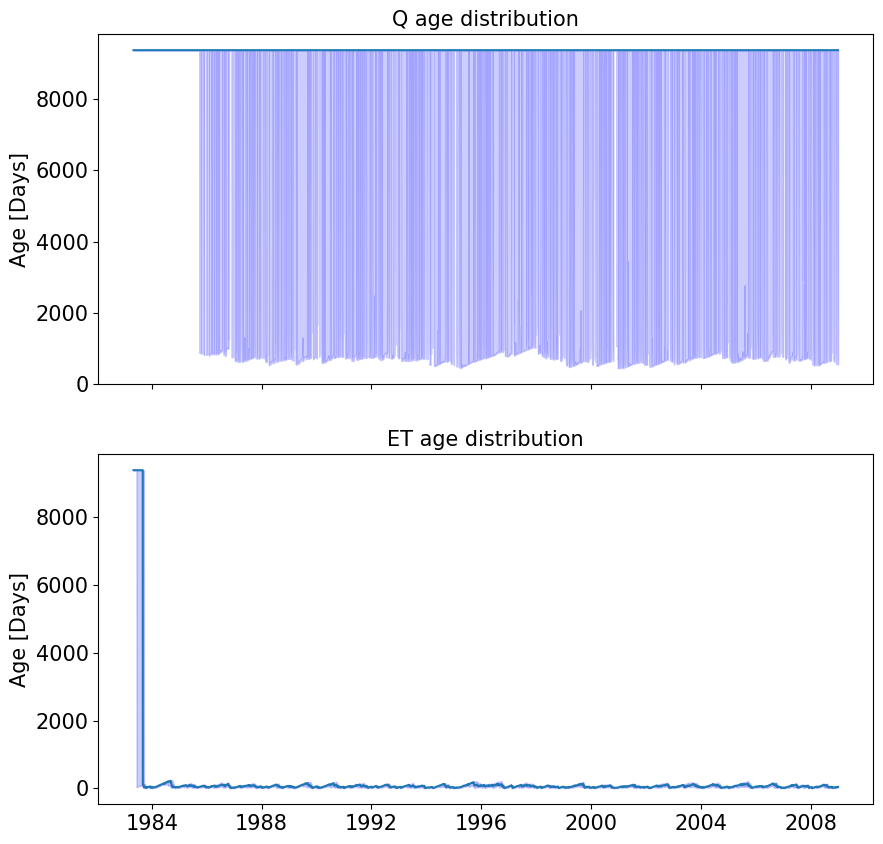

In [17]:
# Initial conditions and sas inputs
nt = Q.size
sTmT_init = jnp.zeros([nt, 2])

sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Run the trained model
sT, mT, mQETs, pQETs, mRs, C_Q = model_mdn(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)

plot_PQET_quantile(pQETs, params['dt'], df.index)


## Save the model

In [21]:
# Save the model
save_transport_model('./transport_model.eqx', transport_params, model_mdn)


## Load the model

In [22]:
# Load the model
model_mdn2 = load_transport_model('./transport_model.eqx')


array([<Axes: title={'center': 'Q age distribution'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution'}, ylabel='Age [Days]'>],
      dtype=object)

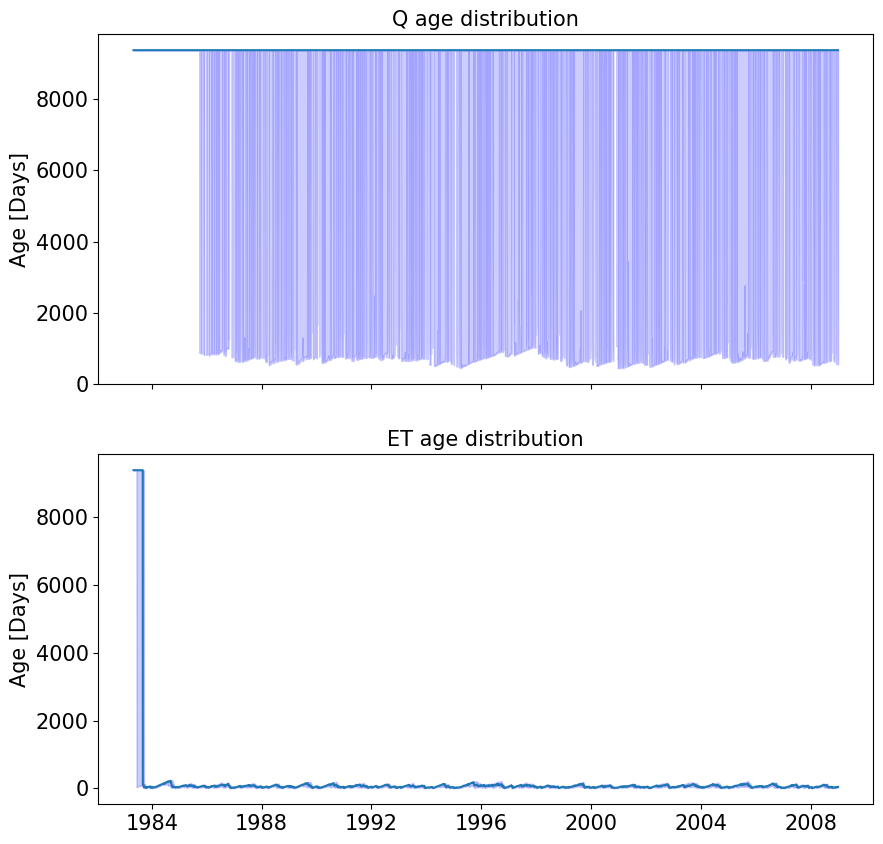

In [23]:
# Run the trained model
sT, mT, mQETs, pQETs, mRs, C_Q = model_mdn2(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)

plot_PQET_quantile(pQETs, params['dt'], df.index)


# Flow model

## Parameters

In [24]:
flow_params = {
    "n_input": 1,
    "n_output": 1,
    "n_hidden": 20,
    "key": 42,
}


## Initialize the model

In [29]:
model_flow = LSTM(**flow_params)
model_flow


LSTM(
  hidden_size=20,
  cell=LSTMCell(
    weight_ih=f32[80,1],
    weight_hh=f32[80,20],
    bias=None,
    input_size=1,
    hidden_size=20,
    use_bias=False
  ),
  linear=Linear(
    weight=f32[1,20],
    bias=f32[1],
    in_features=20,
    out_features=1,
    use_bias=True
  )
)

## Save the model

In [30]:
# Save the model
save_flow_model('./flow_model.eqx', flow_params, model_flow)


## Load the model

In [32]:
# Load the model
model_flow2 = load_flow_model('./flow_model.eqx')


In [33]:
model_flow2

LSTM(
  hidden_size=20,
  cell=LSTMCell(
    weight_ih=f32[80,1],
    weight_hh=f32[80,20],
    bias=None,
    input_size=1,
    hidden_size=20,
    use_bias=False
  ),
  linear=Linear(
    weight=f32[1,20],
    bias=f32[1],
    in_features=20,
    out_features=1,
    use_bias=True
  )
)

# Flow and transport model

## Parameters